# Air Quality Insights & Predictions
## Analysis - Which Areas Need Attention?

This notebook analyzes the air quality data to find patterns, identify worst and best performing states, and make predictions about future trends.

---

## Step 1: Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
data = pd.read_csv('../Data/processed/clean_data.csv')

print("Data loaded successfully!")
print(f"Total Records: {len(data):,}")
print(f"States: {data['state'].nunique()}")
print(f"Areas: {data['area'].nunique()}")
print(f"Date Range: {data['date'].min()} to {data['date'].max()}")

print("\nAir Quality Status Distribution:")
status_dist = data['air_quality_status'].value_counts()
for status, count in status_dist.items():
    pct = (count/len(data))*100
    print(f"   {status}: {count:,} ({pct:.1f}%)")

Data loaded successfully!
Total Records: 425,279
States: 32
Areas: 295
Date Range: 2015-05-01 to 2025-06-19

Air Quality Status Distribution:
   Satisfactory: 155,222 (36.5%)
   Moderate: 138,532 (32.6%)
   Good: 69,754 (16.4%)
   Poor: 43,812 (10.3%)
   Very Poor: 15,392 (3.6%)
   Severe: 2,567 (0.6%)


---
## Finding 1: Most Polluted States
Which states have the highest average AQI values?

Top 10 Most Polluted States (Highest Average AQI):
 1. delhi                → AQI:  215.9
 2. bihar                → AQI:  165.9
 3. himachal pradesh     → AQI:  160.1
 4. uttar pradesh        → AQI:  159.5
 5. haryana              → AQI:  151.5
 6. jharkhand            → AQI:  147.4
 7. rajasthan            → AQI:  130.7
 8. tripura              → AQI:  126.6
 9. odisha               → AQI:  123.7
10. chandigarh           → AQI:  122.8


C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_2788\3947105978.py:18: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\NITISH RANA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


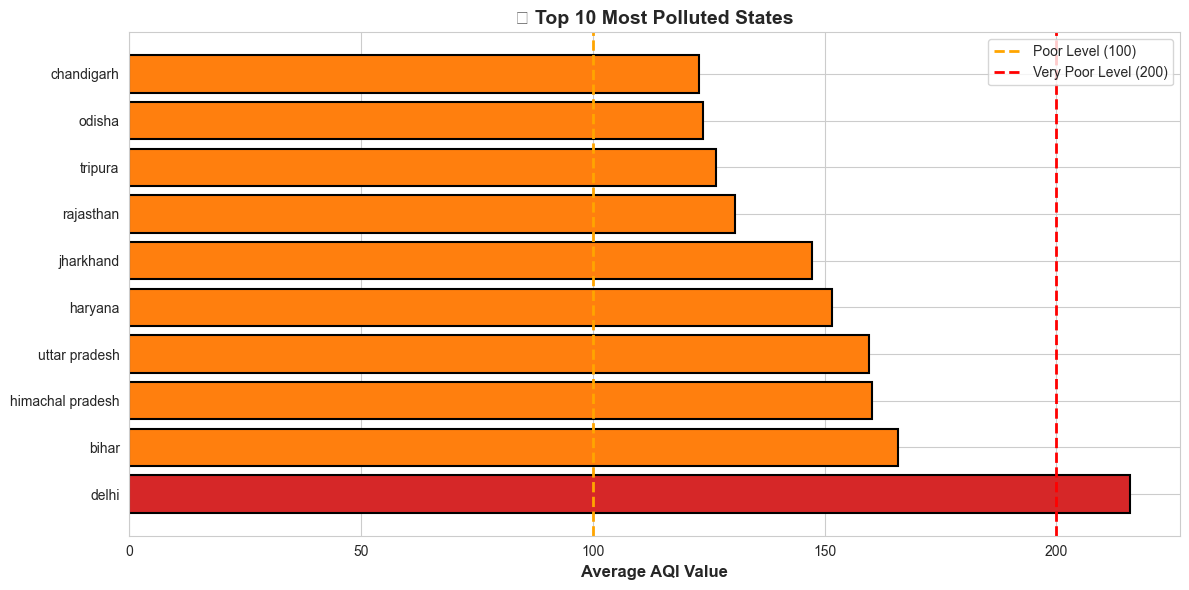


⚠️  INSIGHT: These states need URGENT attention! High pollution levels daily.


In [2]:
# Calculate average AQI per state
worst_states = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10)

print("Top 10 Most Polluted States (Highest Average AQI):")
print("="*60)
for rank, (state, aqi) in enumerate(worst_states.items(), 1):
    print(f"{rank:2d}. {state:20} → AQI: {aqi:6.1f}")

# Visualize
plt.figure(figsize=(12, 6))
colors = ['#d62728' if x > 200 else '#ff7f0e' if x > 100 else '#2ca02c' for x in worst_states.values]
plt.barh(worst_states.index, worst_states.values, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Average AQI Value', fontsize=12, fontweight='bold')
plt.title('🚨 Top 10 Most Polluted States', fontsize=14, fontweight='bold')
plt.axvline(x=100, color='orange', linestyle='--', linewidth=2, label='Poor Level (100)')
plt.axvline(x=200, color='red', linestyle='--', linewidth=2, label='Very Poor Level (200)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n⚠️  INSIGHT: These states need URGENT attention! High pollution levels daily.")

---
## Finding 2: Cleanest States
Which states have the lowest average AQI values?


🟢 TOP 10 CLEANEST STATES (Lowest Average AQI):
 1. mizoram              → AQI:   45.1  🟢 GOOD
 2. meghalaya            → AQI:   52.6  🟡 SATISFACTORY
 3. sikkim               → AQI:   53.5  🟡 SATISFACTORY
 4. puducherry           → AQI:   56.0  🟡 SATISFACTORY
 5. arunachal pradesh    → AQI:   59.9  🟡 SATISFACTORY
 6. andaman and nicobar islands → AQI:   60.5  🟡 SATISFACTORY
 7. karnataka            → AQI:   64.3  🟡 SATISFACTORY
 8. kerala               → AQI:   67.5  🟡 SATISFACTORY
 9. tamil nadu           → AQI:   69.9  🟡 SATISFACTORY
10. chhattisgarh         → AQI:   77.8  🟡 SATISFACTORY


C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_2788\1634167635.py:17: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\NITISH RANA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


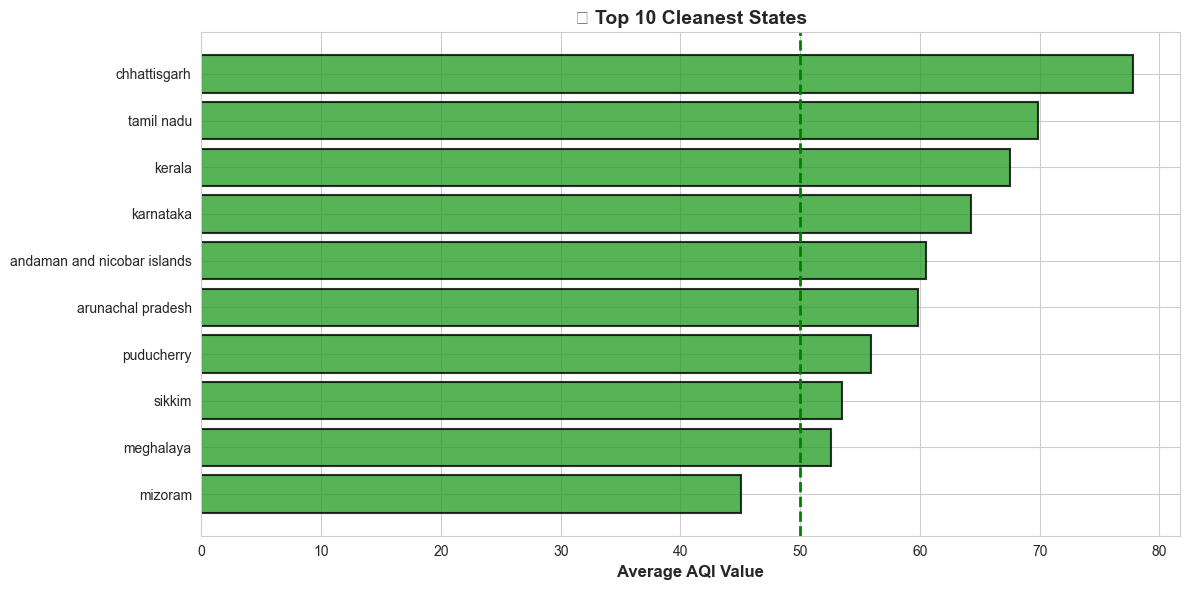


✅ INSIGHT: These states are doing GREAT! Good air quality maintained.


In [3]:
# Find best states
best_states = data.groupby('state')['aqi_value'].mean().sort_values(ascending=True).head(10)

print("\n🟢 TOP 10 CLEANEST STATES (Lowest Average AQI):")
print("="*60)
for rank, (state, aqi) in enumerate(best_states.items(), 1):
    status = "🟢 GOOD" if aqi < 50 else "🟡 SATISFACTORY"
    print(f"{rank:2d}. {state:20} → AQI: {aqi:6.1f}  {status}")

# Visualize
plt.figure(figsize=(12, 6))
colors = ['#2ca02c' for _ in best_states.values]
plt.barh(best_states.index, best_states.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
plt.xlabel('Average AQI Value', fontsize=12, fontweight='bold')
plt.title('🌱 Top 10 Cleanest States', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='green', linestyle='--', linewidth=2, label='Good Level (50)')
plt.tight_layout()
plt.show()

print("\n✅ INSIGHT: These states are doing GREAT! Good air quality maintained.")

---
## Finding 3: Seasonal Patterns
Which months have the worst and best air quality?

Monthly Air Quality Trends:
Jan  (Month  1): AQI =  163.0  
Feb  (Month  2): AQI =  137.8  
Mar  (Month  3): AQI =  121.2  
Apr  (Month  4): AQI =  117.2  
May  (Month  5): AQI =  107.4  
Jun  (Month  6): AQI =   94.2  
Jul  (Month  7): AQI =   67.4  
Aug  (Month  8): AQI =   66.2  (Best)
Sep  (Month  9): AQI =   70.4  
Oct  (Month 10): AQI =  120.9  
Nov  (Month 11): AQI =  174.3  (Worst)
Dec  (Month 12): AQI =  168.2  


C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_2788\1206838202.py:28: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\NITISH RANA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


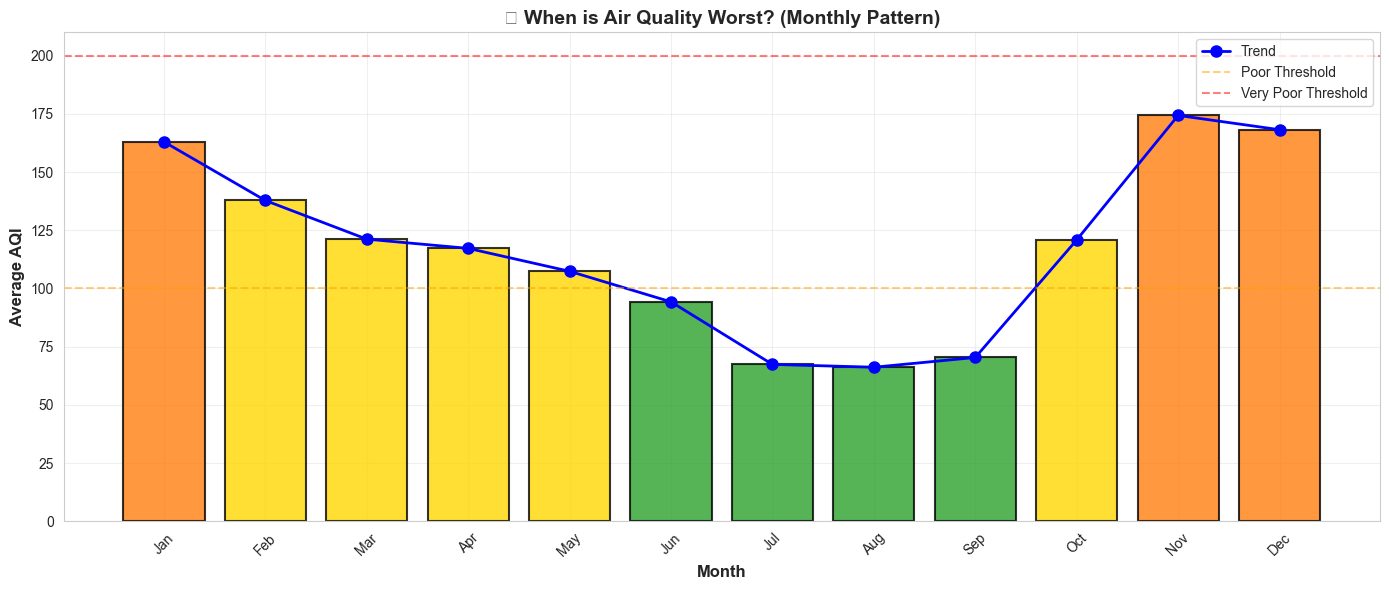


🔴 WORST MONTH: Nov (AQI: 174.3)
🟢 BEST MONTH:  Aug (AQI: 66.2)

⚠️  INSIGHT: Winter months have worse air quality. Prepare for Nov!


In [4]:
# Analyze monthly trends
monthly_avg = data.groupby('month')['aqi_value'].agg(['mean', 'count'])
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("Monthly Air Quality Trends:")
print("="*60)
worst_month = monthly_avg['mean'].idxmax()
best_month = monthly_avg['mean'].idxmin()

for month in range(1, 13):
    avg = monthly_avg.loc[month, 'mean']
    status = "(Worst)" if month == worst_month else "(Best)" if month == best_month else ""
    print(f"{month_names[month-1]:4} (Month {month:2d}): AQI = {avg:6.1f}  {status}")

# Visualize
plt.figure(figsize=(14, 6))
colors = ['#d62728' if x > 200 else '#ff7f0e' if x > 150 else '#ffd700' if x > 100 else '#2ca02c' for x in monthly_avg['mean']]
bars = plt.bar(range(1, 13), monthly_avg['mean'], color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
plt.plot(range(1, 13), monthly_avg['mean'], 'b-o', linewidth=2, markersize=8, label='Trend')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Average AQI', fontsize=12, fontweight='bold')
plt.title('📅 When is Air Quality Worst? (Monthly Pattern)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), month_names, rotation=45)
plt.axhline(y=100, color='orange', linestyle='--', alpha=0.5, label='Poor Threshold')
plt.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Very Poor Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🔴 WORST MONTH: {month_names[worst_month-1]} (AQI: {monthly_avg.loc[worst_month, 'mean']:.1f})")
print(f"🟢 BEST MONTH:  {month_names[best_month-1]} (AQI: {monthly_avg.loc[best_month, 'mean']:.1f})")
print(f"\n⚠️  INSIGHT: Winter months have worse air quality. Prepare for {month_names[worst_month-1]}!")

---
## Finding 4: Critical State-Month Combinations
Which state-month pairs have the worst air quality?

In [5]:
# Find worst combinations
state_month_avg = data.groupby(['state', 'month'])['aqi_value'].mean().sort_values(ascending=False).head(15)

print("Top 15 Most Dangerous State-Month Combinations:")
print("="*70)
for rank, ((state, month), aqi) in enumerate(state_month_avg.items(), 1):
    month_name = month_names[month-1]
    print(f"{rank:2d}. {state:20} in {month_name:4} → AQI: {aqi:6.1f}")

print("\nAction Items:")
print("  - Plan health campaigns for critical months")
print("  - Issue early warnings in high-risk areas")
print("  - Increase monitoring during peak seasons")

Top 15 Most Dangerous State-Month Combinations:
 1. delhi                in Nov  → AQI:  351.2
 2. delhi                in Dec  → AQI:  330.8
 3. delhi                in Jan  → AQI:  318.9
 4. bihar                in Dec  → AQI:  267.8
 5. uttar pradesh        in Nov  → AQI:  263.0
 6. himachal pradesh     in Jan  → AQI:  262.8
 7. bihar                in Jan  → AQI:  259.2
 8. haryana              in Nov  → AQI:  252.6
 9. delhi                in Feb  → AQI:  246.9
10. delhi                in Oct  → AQI:  242.0
11. uttar pradesh        in Dec  → AQI:  242.0
12. bihar                in Nov  → AQI:  241.9
13. himachal pradesh     in Dec  → AQI:  223.8
14. uttar pradesh        in Jan  → AQI:  223.3
15. tripura              in Jan  → AQI:  222.3

Action Items:
  - Plan health campaigns for critical months
  - Issue early warnings in high-risk areas
  - Increase monitoring during peak seasons


---
## Finding 5: Overall Air Quality Status
How many days fall into each air quality category?

Air Quality Status Distribution:
Good            ██████  16.4% (69,754 days)
Satisfactory    ██████████████  36.5% (155,222 days)
Moderate        █████████████  32.6% (138,532 days)
Poor            ████  10.3% (43,812 days)
Very Poor       █   3.6% (15,392 days)
Severe             0.6% (2,567 days)


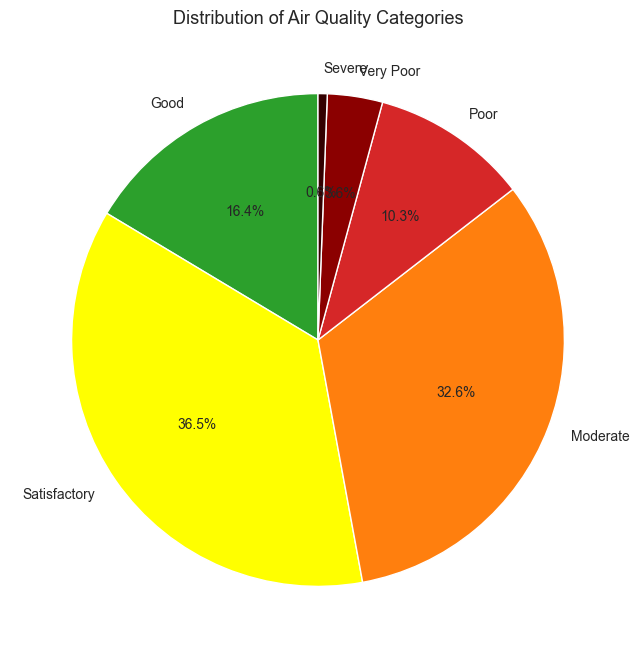

Safe Days (Good + Satisfactory): 52.9%
Unsafe Days (Poor + Very Poor + Severe): 14.5%


In [9]:
# Status breakdown
status_counts = data['air_quality_status'].value_counts()
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
status_counts = status_counts.reindex(status_order)

print("Air Quality Status Distribution:")
print("="*70)

for status, count in status_counts.items():
    pct = (count/len(data))*100
    bar = '█' * int(pct/2.5)  # Visual representation
    print(f"{status:15} {bar} {pct:5.1f}% ({count:,} days)")

# Pie chart
plt.figure(figsize=(10, 8))
colors_pie = ['#2ca02c', '#ffff00', '#ff7f0e', '#d62728', '#8b0000', '#330000']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
        colors=colors_pie, startangle=90)
plt.title('Distribution of Air Quality Categories', fontsize=13)
plt.show()

# Calculate safe vs unsafe
safe_pct = (status_counts['Good'] + status_counts['Satisfactory']) / len(data) * 100
unsafe_pct = (status_counts['Poor'] + status_counts['Very Poor'] + status_counts['Severe']) / len(data) * 100

print(f"Safe Days (Good + Satisfactory): {safe_pct:.1f}%")
print(f"Unsafe Days (Poor + Very Poor + Severe): {unsafe_pct:.1f}%")

---
## Finding 6: Trend Analysis
Are the worst states getting better or worse over time?

In [13]:
# Analyze trends for worst states
print("Trend Analysis - Top 10 Worst States:")
print("="*70)
print("(Comparing early period vs recent period)")
print("="*70)

worst_10_states = worst_states.head(10).index.tolist()
trends = []

for state in worst_10_states:
    state_data = data[data['state'] == state].sort_values('date')
    
    # Split data chronologically
    mid_point = len(state_data) // 2
    early_aqi = state_data.iloc[:mid_point]['aqi_value'].mean()
    recent_aqi = state_data.iloc[mid_point:]['aqi_value'].mean()
    change = recent_aqi - early_aqi
    change_pct = (change / early_aqi) * 100
    
    trend = "WORSENING" if change > 0 else "IMPROVING"
    print(f"{state:20} → {trend:10} ({change:+.1f} AQI, {change_pct:+.1f}%)")
    trends.append((state, change))

print("\nInterpretation: Positive change = Worsening, Negative change = Improving")

Trend Analysis - Top 10 Worst States:
(Comparing early period vs recent period)
delhi                → IMPROVING  (-20.7 AQI, -9.2%)
bihar                → IMPROVING  (-57.1 AQI, -29.4%)
himachal pradesh     → WORSENING  (+16.0 AQI, +10.5%)
uttar pradesh        → IMPROVING  (-69.1 AQI, -35.6%)
haryana              → IMPROVING  (-2.8 AQI, -1.8%)
jharkhand            → WORSENING  (+18.7 AQI, +13.5%)
rajasthan            → WORSENING  (+0.8 AQI, +0.6%)
tripura              → WORSENING  (+24.4 AQI, +21.3%)
odisha               → IMPROVING  (-27.7 AQI, -20.1%)
chandigarh           → WORSENING  (+38.2 AQI, +36.9%)

Interpretation: Positive change = Worsening, Negative change = Improving


---
## Summary & Key Findings

In [14]:
print("\n" + "="*70)
print("SUMMARY OF KEY FINDINGS")
print("="*70)

print(f"\n1. Most Polluted State:")
print(f"   {worst_states.index[0]} (AQI: {worst_states.iloc[0]:.1f})")

print(f"\n2. Cleanest State:")
print(f"   {best_states.index[0]} (AQI: {best_states.iloc[0]:.1f})")

print(f"\n3. Worst Performing Month:")
worst_m = worst_month
print(f"   {month_names[worst_m-1]} (AQI: {monthly_avg.loc[worst_m, 'mean']:.1f})")

print(f"\n4. Best Performing Month:")
best_m = best_month
print(f"   {month_names[best_m-1]} (AQI: {monthly_avg.loc[best_m, 'mean']:.1f})")

print(f"\n5. Air Quality Safety:")
print(f"   Only {safe_pct:.1f}% of days have safe air quality")
print(f"   {unsafe_pct:.1f}% of days are unsafe")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("\n1. Focus intervention resources on top 3 worst states:")
for i, state in enumerate(worst_states.head(3).index, 1):
    print(f"   {i}. {state}")

print(f"\n2. Implement seasonal alert system for {month_names[worst_month-1]} season")
print("\n3. Study best practices from cleanest states")
print("\n4. Increase monitoring station density in high-risk areas")
print("\n5. Public awareness campaigns for critical state-month combinations")
print("\n" + "="*70)


SUMMARY OF KEY FINDINGS

1. Most Polluted State:
   delhi (AQI: 215.9)

2. Cleanest State:
   mizoram (AQI: 45.1)

3. Worst Performing Month:
   Nov (AQI: 174.3)

4. Best Performing Month:
   Aug (AQI: 66.2)

5. Air Quality Safety:
   Only 52.9% of days have safe air quality
   14.5% of days are unsafe

RECOMMENDATIONS

1. Focus intervention resources on top 3 worst states:
   1. delhi
   2. bihar
   3. himachal pradesh

2. Implement seasonal alert system for Nov season

3. Study best practices from cleanest states

4. Increase monitoring station density in high-risk areas

5. Public awareness campaigns for critical state-month combinations



---
## Comparison: Worst vs Best States
Side-by-side comparison of top performers

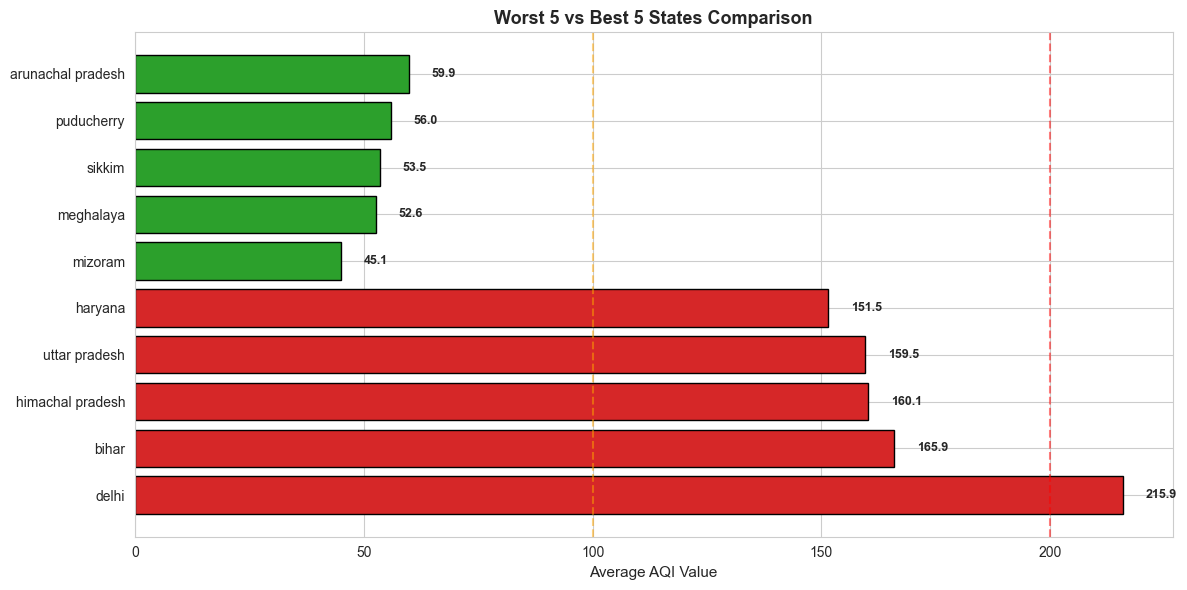


Statistics:
  Worst 5 Average: 170.6
  Best 5 Average:  53.4
  Difference:      117.2 AQI points

  This represents 220% increase


In [15]:
# Compare top 5 worst and best
comparison_data = pd.concat([
    worst_states.head(5),
    best_states.head(5)
])

fig, ax = plt.subplots(figsize=(12, 6))
colors_comp = ['#d62728']*5 + ['#2ca02c']*5
bars = ax.barh(range(len(comparison_data)), comparison_data.values, color=colors_comp, edgecolor='black', linewidth=1)

ax.set_yticks(range(len(comparison_data)))
ax.set_yticklabels(comparison_data.index, fontsize=10)
ax.set_xlabel('Average AQI Value', fontsize=11)
ax.set_title('Worst 5 vs Best 5 States Comparison', fontsize=13, fontweight='bold')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, comparison_data.values)):
    ax.text(value + 5, i, f'{value:.1f}', va='center', fontweight='bold', fontsize=9)

ax.axvline(x=100, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=200, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(f"  Worst 5 Average: {worst_states.head(5).mean():.1f}")
print(f"  Best 5 Average:  {best_states.head(5).mean():.1f}")
print(f"  Difference:      {worst_states.head(5).mean() - best_states.head(5).mean():.1f} AQI points")
print(f"\n  This represents {((worst_states.head(5).mean() - best_states.head(5).mean())/best_states.head(5).mean()*100):.0f}% increase")